# Ball-level run prediction

Predicts the **conditional** distribution of runs off the bat given that a delivery is legal:
how likely each of 0, 1, 2, 3, 4 and 6 is.

Same parquet as the wicket notebook, built by `build_ball_data.py`, and the same rule: every
feature describes the state of the match *before* the delivery, and career/venue/matchup
features are snapshots from strictly earlier matches. The checks below verify the intended
pre-ball construction; evaluation leakage is discussed separately.

Three framing decisions, all of which matter more than the model choice:

- The outcome is categorical, not continuous. Runs off the bat take six values and the gaps
  are real: a ball is 40× more likely to go for 4 than for 3. A regression on runs spends its
  capacity on a number line that is mostly empty, and its residuals are wildly non-Gaussian. We
  fit a 6-way multinomial and read expected runs off the predicted distribution when a point
  estimate is wanted.
- Legal deliveries only. This is a conditional model: legality is not known before the bowler
  releases the ball. An unconditional live predictor or simulator also needs a legality/extras
  model. Wides and no-balls are 3.8% of rows.
- The bar is the training prior, not accuracy. Predicting "1 run" on every ball scores 38%
  accuracy and is worth nothing. We score multiclass log loss against the prior, plus RMSE of
  expected runs and calibration.

Unlike wickets, there is real signal here: expect roughly a 3–4% log-loss gain rather than 2%.
Whether a batter *scores* is more predictable than whether they get out.


### Evaluation status

"
            "This is a strong exploratory backtest, not a pristine one-shot holdout. Earlier versions of
"
            "the analysis repeatedly inspected 2025–26 during ablation, pruning, calibration choice and
"
            "style-feature experiments. Temporal splitting prevents future rows entering model fitting, but
"
            "repeated analyst use of the final period can still bias model-selection claims. Small deltas
"
            "should be confirmed by a future season or a rolling-origin evaluation.

"
            "Final comparisons therefore include paired 95% bootstrap intervals that resample whole matches.
"
            "Random-seed variation only measures optimiser stability and is not a confidence interval.

In [1]:
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import xgboost as xgb
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, SplineTransformer, StandardScaler

# feature lists and the labelling rule live in the script so notebook and script never drift
from model_baseline import CATEGORICAL, LINEAR, SPLINE
from model_runs import CATS, FEATS, OUTCOMES, expected_runs, frames, label
from evaluation import clustered_log_loss_gain

BLUE, ORANGE, GREY, GREEN = "#2a78d6", "#eb6834", "#8a8a85", "#3f9e6a"
plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False,
                     "axes.spines.right": False, "axes.grid": True,
                     "grid.alpha": 0.25, "grid.linewidth": 0.6, "font.size": 9})

raw = pl.read_parquet("ball_data.parquet")
df = label(raw)          # legal balls only, runs off the bat -> class index 0..5
print(f"{raw.height:,} deliveries -> {df.height:,} legal  "
      f"({100 * (1 - df.height / raw.height):.1f}% wides/no-balls dropped)")
print(f"{df['match_id'].n_unique():,} matches · {df['year'].min()}-{df['year'].max()}")
print(f"mean runs off the bat: {df['_runs'].mean():.4f} per legal ball")


# Fail early if the generated table no longer matches the notebook's assumptions.
required = {"runs_batter", "is_legal", "match_id", "year", "over", "legal_balls"}
assert not (required - set(raw.columns)), f"missing columns: {sorted(required - set(raw.columns))}"
assert raw["runs_batter"].null_count() == 0
assert set(df["_runs"].unique().to_list()) == set(OUTCOMES)
assert df.select(pl.struct(["match_id", "innings", "over", "ball_in_over"]).n_unique()).item() == df.height


295,557 deliveries -> 284,465 legal  (3.8% wides/no-balls dropped)
1,243 matches · 2008-2026
mean runs off the bat: 1.3340 per legal ball


## The shape of the outcome

Three quarters of legal balls are a dot or a single. Boundaries are 18% of balls but 61% of the
runs, which is why a model that only gets the mean right is not much use: the interesting
question at any point in an innings is *how likely is a boundary*, not *what is the average*.


_runs,n,share,runs,run_share
i64,u32,f64,i64,f64
0,106303,0.373694,0,0.0
1,109053,0.383362,109053,0.287386
2,18259,0.064187,36518,0.096235
3,842,0.00296,2526,0.006657
4,34340,0.120718,137360,0.361983
6,15668,0.055079,94008,0.247738


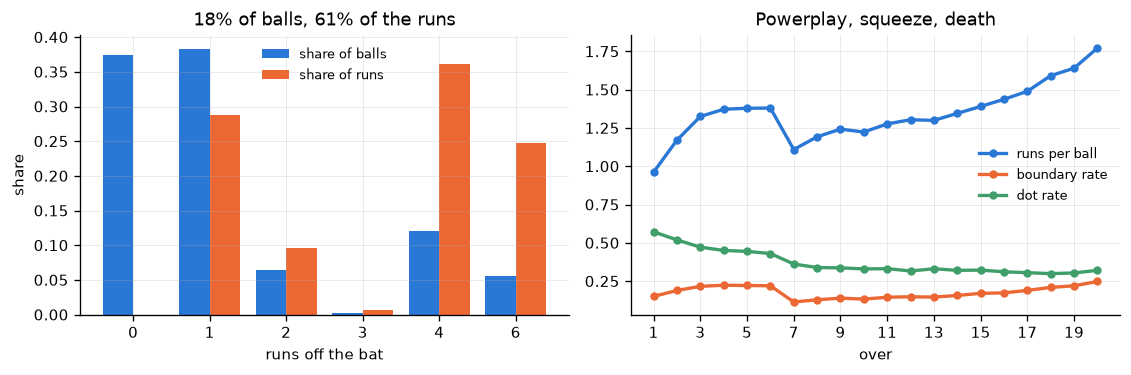

In [2]:
mix = (df.group_by("_runs").agg(pl.len().alias("n"))
         .with_columns((pl.col("n") / df.height).alias("share"),
                       (pl.col("_runs") * pl.col("n")).alias("runs"))
         .with_columns((pl.col("runs") / pl.col("runs").sum()).alias("run_share"))
         .sort("_runs"))
display(mix)

fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.2))
x = np.arange(len(OUTCOMES))
axes[0].bar(x - 0.2, mix["share"], width=0.4, color=BLUE, label="share of balls")
axes[0].bar(x + 0.2, mix["run_share"], width=0.4, color=ORANGE, label="share of runs")
axes[0].set(xticks=x, xlabel="runs off the bat", ylabel="share",
            title="18% of balls, 61% of the runs")
axes[0].set_xticklabels(OUTCOMES)
axes[0].legend(frameon=False, fontsize=8)

by_over = (df.filter(pl.col("over") < 20).group_by("over")
             .agg(pl.col("_runs").mean().alias("runs per ball"),
                  (pl.col("_runs") >= 4).mean().alias("boundary rate"),
                  (pl.col("_runs") == 0).mean().alias("dot rate")).sort("over"))
for col, colour in [("runs per ball", BLUE), ("boundary rate", ORANGE), ("dot rate", GREEN)]:
    axes[1].plot(by_over["over"] + 1, by_over[col], "o-", color=colour, lw=2, ms=4, label=col)
axes[1].set(xlabel="over", title="Powerplay, squeeze, death",
            xticks=range(1, 21, 2))
axes[1].legend(frameon=False, fontsize=8)
plt.tight_layout()


Note the shape in the right panel, because it is the single most important thing the model has
to learn and it is **not** the monotone climb that the wicket rate showed. Scoring rises through
the powerplay, falls off a cliff the moment the field goes out (boundary rate halves from 0.220
in over 6 to 0.114 in over 7), then climbs back through the middle and steeply at the death.

The dot rate does *not* mirror it: it keeps falling straight through that cliff (0.431 to 0.362)
and only turns up in the last over. Batters do not stop scoring when the field spreads, they
switch from boundaries to rotating strike. Boundary rate in over 5 (0.222) is close to over 20
(0.248) and the balls that produce them have almost nothing else in common, which is why
`is_powerplay` turns out to be worth more to the model than `over` itself.


## Split: temporal, never random

Balls from the same over are near-duplicates. A random split would let the model memorise a match
and report a score it cannot reproduce on a future game.


In [3]:
levels, (train, val, test) = frames()
ytr, yva, yte = (d["y"].to_numpy() for d in (train, val, test))

PRIOR = np.bincount(ytr, minlength=len(OUTCOMES)) / len(ytr)   # everything is scored against this
LABELS = list(range(len(OUTCOMES)))
runs_te = np.array(OUTCOMES, dtype=float)[yte]                 # actual runs on each test ball

for name, d, y in [("train", train, ytr), ("val", val, yva), ("test", test, yte)]:
    print(f"{name:6s} {d.height:>7,} balls  {d['year'].min()}-{d['year'].max()}  "
          f"mean runs {np.array(OUTCOMES, float)[y].mean():.4f}")

print("\ntrain prior:  " + "  ".join(f"{v}:{p:.4f}" for v, p in zip(OUTCOMES, PRIOR)))

NULL = np.tile(PRIOR / PRIOR.sum(), (len(yte), 1))
NULL_LL = log_loss(yte, NULL, labels=LABELS)
NULL_RMSE = float(np.sqrt(np.mean((expected_runs(NULL) - runs_te) ** 2)))
print(f"null log loss {NULL_LL:.5f} · null E[runs] RMSE {NULL_RMSE:.4f}")


assert train["year"].max() < val["year"].min() <= val["year"].max() < test["year"].min()
assert set(train["match_id"].unique()).isdisjoint(set(val["match_id"].unique()))
assert set(train["match_id"].unique()).isdisjoint(set(test["match_id"].unique()))


train  234,995 balls  2008-2023  mean runs 1.2923
val     16,299 balls  2024-2024  mean runs 1.5048
test    33,171 balls  2025-2026  mean runs 1.5448

train prior:  0:0.3805  1:0.3839  2:0.0653  3:0.0032  4:0.1174  6:0.0498
null log loss 1.40050 · null E[runs] RMSE 1.8607


## Baseline: multinomial logistic regression with splines

Same preprocessing as the wicket baseline (spline bases on the features whose effect is curved,
plain standardised terms on the rest), but the head is a 6-way softmax instead of a binary
logit. Splines earn their place more here than they did for wickets: `over` has a genuine
non-monotone effect on scoring (up, down, flat, up), and no single linear coefficient can
express that.


In [4]:
FE = SPLINE + LINEAR + CATEGORICAL
X = lambda d: d.select(FE).to_pandas()

# SimpleImputer runs first: the chase features (rrr, balls_left, ...) are null for every
# first-innings ball, and SplineTransformer cannot take NaN. add_indicator keeps a flag so
# the model still knows the value was missing rather than median.
pre = ColumnTransformer([
    ("spline", Pipeline([
        ("impute", SimpleImputer(strategy="median", add_indicator=True)),
        ("spline", SplineTransformer(n_knots=6, degree=3, include_bias=False)),
        ("scale", StandardScaler()),
    ]), SPLINE),
    ("linear", Pipeline([
        ("impute", SimpleImputer(strategy="median", add_indicator=True)),
        ("scale", StandardScaler()),
    ]), LINEAR),
    ("cat", OneHotEncoder(handle_unknown="ignore", drop="first"), CATEGORICAL),
])

lr = Pipeline([("pre", pre), ("lr", LogisticRegression(max_iter=1000, C=1.0))])
lr.fit(X(train), ytr)

print(f"{len(FE)} features -> {lr.named_steps['pre'].transform(X(val)).shape[1]} columns "
      f"-> {len(OUTCOMES)} class probabilities")


36 features -> 103 columns -> 6 class probabilities


## Scoring

Four numbers, because no single one covers a distributional forecast:

- **Multiclass log loss** against the training prior. The headline.
- **RMSE of expected runs**, the price of using the model as a point predictor. It will barely
  move, because the irreducible variance of a single ball is enormous, and that is the point.
- **Boundary AUC**: can the model rank the balls that go for 4 or 6? This is where the usable
  signal lives.
- **Dot AUC**, the same question at the other end.


In [5]:
def norm(p):
    """Guard against float drift so log_loss does not complain."""
    return p / p.sum(axis=1, keepdims=True)


def report(name, y, p, runs=None):
    p = norm(p)
    ll = log_loss(y, p, labels=LABELS)
    null_ll = log_loss(y, np.tile(PRIOR, (len(y), 1)), labels=LABELS)
    runs = np.array(OUTCOMES, float)[y] if runs is None else runs
    rmse = np.sqrt(np.mean((expected_runs(p) - runs) ** 2))
    bnd = roc_auc_score((y >= 4).astype(int), p[:, 4] + p[:, 5])
    dot = roc_auc_score((y == 0).astype(int), p[:, 0])
    print(f"{name:6s} logloss {ll:.5f}  vs null {null_ll:.5f} "
          f"({100 * (null_ll - ll) / null_ll:+.2f}%)   E[runs] RMSE {rmse:.4f}   "
          f"boundary AUC {bnd:.4f}   dot AUC {dot:.4f}")


for name, d, y in [("train", train, ytr), ("val", val, yva), ("test", test, yte)]:
    report(name, y, lr.predict_proba(X(d)))


train  logloss 1.28270  vs null 1.33259 (+3.74%)   E[runs] RMSE 1.6035   boundary AUC 0.6296   dot AUC 0.6292
val    logloss 1.34244  vs null 1.39681 (+3.89%)   E[runs] RMSE 1.7766   boundary AUC 0.6344   dot AUC 0.6104
test   logloss 1.35260  vs null 1.40050 (+3.42%)   E[runs] RMSE 1.8236   boundary AUC 0.6154   dot AUC 0.6115


## Calibration

For a distributional model this is the thing that matters. Two views: the point estimate (when
the model says 1.6 expected runs, do those balls average 1.6?) and the boundary probability
(when it says 25%, is it 25%?).


b,n,predicted,actual
cat,u32,f64,f64
"""0""",3318,0.848114,0.950271
"""1""",3317,1.083107,1.203497
"""2""",3317,1.228153,1.343081
"""3""",3317,1.342157,1.424178
"""4""",3317,1.442082,1.49593
"""5""",3317,1.543165,1.565873
"""6""",3317,1.655089,1.715104
"""7""",3317,1.796529,1.79801
"""8""",3317,2.00389,1.907748


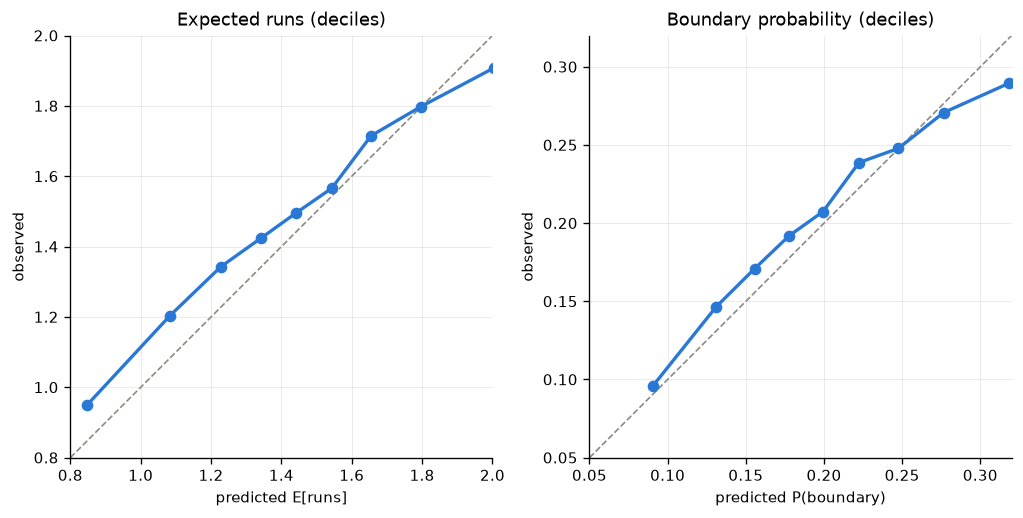

In [6]:
p_lr = norm(lr.predict_proba(X(test)))


def cal_curve(score, actual, bins=10):
    return (pl.DataFrame({"s": score, "a": actual.astype(float)})
              .with_columns(pl.col("s").qcut(bins, labels=[str(i) for i in range(bins)])
                              .alias("b"))
              .group_by("b").agg(pl.len().alias("n"),
                                 pl.col("s").mean().alias("predicted"),
                                 pl.col("a").mean().alias("actual")).sort("b"))


e_lr = cal_curve(expected_runs(p_lr), runs_te)
b_lr = cal_curve(p_lr[:, 4] + p_lr[:, 5], (yte >= 4).astype(int))
display(e_lr)

fig, axes = plt.subplots(1, 2, figsize=(8.6, 4.2))
for ax, c, lo, hi, xl, t in [
        (axes[0], e_lr, 0.8, 2.0, "predicted E[runs]", "Expected runs (deciles)"),
        (axes[1], b_lr, 0.05, 0.32, "predicted P(boundary)", "Boundary probability (deciles)")]:
    ax.plot([lo, hi], [lo, hi], color=GREY, lw=1, ls="--")
    ax.plot(c["predicted"], c["actual"], "o-", color=BLUE, lw=2, ms=6)
    ax.set(xlabel=xl, ylabel="observed", title=t, xlim=(lo, hi), ylim=(lo, hi))
    ax.set_aspect("equal")
plt.tight_layout()


---

# Gradient boosting

Trees should do better here for the same reasons as in the wicket model: thresholds found
without a spline basis, and interactions an additive model cannot express. The interaction that
matters most for runs is `over` × `wickets_in_hand`: at over 18 with 8 wickets in hand the batting
side swings at everything, and at over 18 with 1 wicket left it does not. The logistic regression
has to average those two situations together.

`ground` joins as a native categorical. The wicket notebook found venue worth nothing, but noted
that grounds differ substantially in *scoring* (1.30 to 1.51 runs per ball), so this is the
model where it should finally pay. The ablation below tests that.


In [7]:
def frame(d, feats=FEATS):
    """Trees take features raw: no splines, no scaling, NaN handled natively."""
    Xd = d.select(feats).to_pandas()
    for c in CATS:
        if c in feats:
            Xd[c] = pd.Categorical(Xd[c], categories=levels[c])
    return Xd


Xtr, Xva, Xte = (frame(d) for d in (train, val, test))

PARAMS = dict(objective="multiclass", num_class=len(OUTCOMES), n_estimators=3000,
              learning_rate=0.03, num_leaves=15, min_child_samples=400, subsample=0.8,
              subsample_freq=1, colsample_bytree=0.7, reg_lambda=10.0, verbose=-1)

lgbm = lgb.LGBMClassifier(**PARAMS, random_state=0)
lgbm.fit(Xtr, ytr, eval_X=Xva, eval_y=yva, eval_metric="multi_logloss",
         callbacks=[lgb.early_stopping(100, verbose=False)])

xgbm = xgb.XGBClassifier(
    objective="multi:softprob", num_class=len(OUTCOMES), n_estimators=3000,
    learning_rate=0.03, max_depth=4, min_child_weight=50, subsample=0.8,
    colsample_bytree=0.7, reg_lambda=10.0, enable_categorical=True, tree_method="hist",
    eval_metric="mlogloss", early_stopping_rounds=100, random_state=0)
xgbm.fit(Xtr, ytr, eval_set=[(Xva, yva)], verbose=False)

print(f"LightGBM stopped at {lgbm.best_iteration_} rounds "
      f"({lgbm.best_iteration_ * len(OUTCOMES)} trees, one per class per round)")
print(f"XGBoost  stopped at {xgbm.best_iteration} rounds")


LightGBM stopped at 258 rounds (1548 trees, one per class per round)
XGBoost  stopped at 444 rounds


In [8]:
preds = {
    "null (train prior)": NULL,
    "multinomial + splines": p_lr,
    "lightgbm": norm(lgbm.predict_proba(Xte)),
    "xgboost": norm(xgbm.predict_proba(Xte)),
}
preds["lgb + xgb"] = (preds["lightgbm"] + preds["xgboost"]) / 2

rows = []
for name, p in preds.items():
    p = norm(p)                       # float drift alone is enough to upset log_loss
    ll = log_loss(yte, p, labels=LABELS)
    null_row = name.startswith("null")
    rows.append({"model": name, "logloss": round(ll, 5),
                 "gain_%": round(100 * (NULL_LL - ll) / NULL_LL, 2),
                 "E_runs_RMSE": round(float(np.sqrt(np.mean((expected_runs(p) - runs_te) ** 2))), 4),
                 "boundary_AUC": None if null_row else round(roc_auc_score((yte >= 4).astype(int), p[:, 4] + p[:, 5]), 4),
                 "dot_AUC": None if null_row else round(roc_auc_score((yte == 0).astype(int), p[:, 0]), 4)})
display(pl.DataFrame(rows))


model,logloss,gain_%,E_runs_RMSE,boundary_AUC,dot_AUC
str,f64,f64,f64,f64,f64
"""null (train prior)""",1.4005,0.0,1.8607,null,null
"""multinomial + splines""",1.3526,3.42,1.8236,0.6154,0.6115
"""lightgbm""",1.35142,3.5,1.8205,0.6158,0.6156
"""xgboost""",1.35084,3.55,1.8201,0.6156,0.6158
"""lgb + xgb""",1.35082,3.55,1.8202,0.6159,0.6158


### Where the gain is, class by class

The single log-loss number hides which parts of the distribution improved. Splitting it into six
one-vs-rest problems is worth doing because the answer is not uniform.


In [9]:
p_lgb = preds["lightgbm"]
rows = []
for i, v in enumerate(OUTCOMES):
    yb = (yte == i).astype(int)
    base = np.full(len(yb), PRIOR[i])
    rows.append({"runs": v, "share": round(float(yb.mean()), 4),
                 "AUC": round(roc_auc_score(yb, p_lgb[:, i]), 4),
                 "logloss": round(log_loss(yb, p_lgb[:, i], labels=[0, 1]), 5),
                 "vs_prior_%": round(100 * (log_loss(yb, base, labels=[0, 1])
                                            - log_loss(yb, p_lgb[:, i], labels=[0, 1]))
                                     / log_loss(yb, base, labels=[0, 1]), 2)})
display(pl.DataFrame(rows))


runs,share,AUC,logloss,vs_prior_%
i64,f64,f64,f64,f64
0,0.3395,0.6156,0.62381,3.18
1,0.382,0.6147,0.64603,2.86
2,0.0566,0.5787,0.21618,0.96
3,0.0018,0.6309,0.01314,3.34
4,0.1381,0.5999,0.39431,2.26
6,0.082,0.6282,0.27835,4.93


The six is the most predictable outcome in this backtest, at 4.9% over its prior and AUC 0.628,
comfortably ahead of the dot (3.2%) and the four (2.3%). That ordering makes sense: a six needs a
batter who clears the rope and a situation that asks them to, and both are things the feature set
knows. A four is much more often a good ball that beat the field.

The twos are the floor at 1.0%, which is also as expected: running two is a function of where
the ball goes and how fast the fielder is, not of the match state. (The 3s row reads 2.8% but
that class is 0.18% of balls, so it is noise.)

### Did it capture the shape?

Compare the model's mean prediction against the observed rate, bucketed by a real feature. As in
the wicket notebook this is deliberately *not* a partial-dependence sweep: `over`, `legal_balls`,
`phase` and `is_powerplay` all encode "how late is it", the fit splits that effect across them,
and varying one alone describes deliveries that never occur.


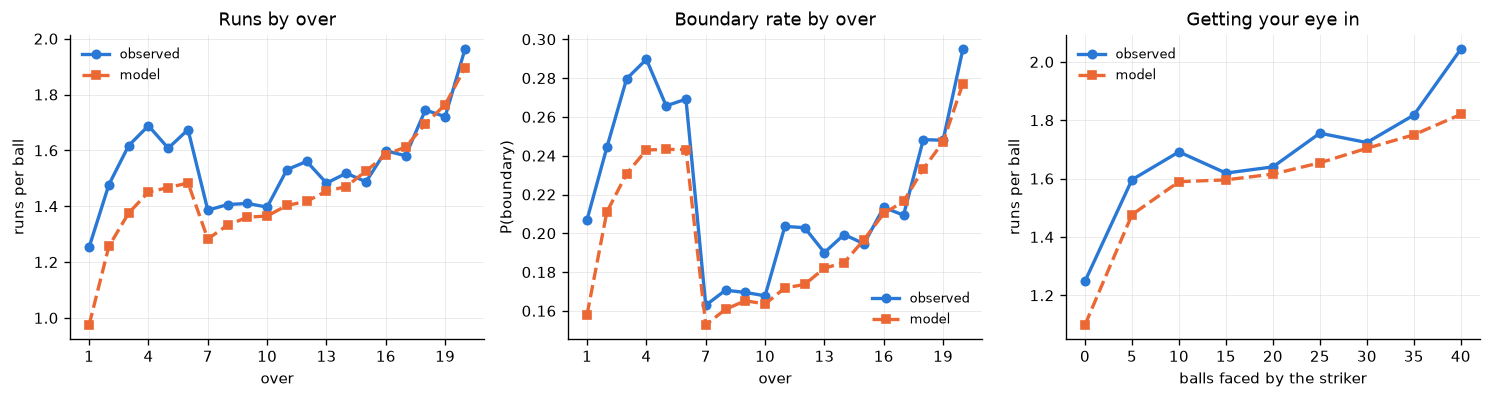

In [10]:
scored = test.with_columns(pl.Series("e_runs", expected_runs(p_lgb)),
                           pl.Series("p_bnd", p_lgb[:, 4] + p_lgb[:, 5]))


def shape(expr, xlabel, ax, pred, obs, min_n=300):
    g = (scored.with_columns(expr.alias("bucket"))
                .group_by("bucket").agg(pl.len().alias("n"),
                                        pl.col(pred).mean().alias("predicted"),
                                        obs.mean().alias("actual"))
                .filter(pl.col("n") >= min_n).sort("bucket"))
    ax.plot(g["bucket"], g["actual"], "o-", color=BLUE, lw=2, ms=5, label="observed")
    ax.plot(g["bucket"], g["predicted"], "s--", color=ORANGE, lw=2, ms=5, label="model")
    ax.set(xlabel=xlabel)
    ax.legend(frameon=False, fontsize=8)
    return g


fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.4))
shape(pl.col("over") + 1, "over", axes[0], "e_runs", pl.col("_runs"))
axes[0].set(ylabel="runs per ball", title="Runs by over", xticks=range(1, 21, 3))
shape(pl.col("over") + 1, "over", axes[1], "p_bnd", (pl.col("_runs") >= 4).cast(pl.Float64))
axes[1].set(ylabel="P(boundary)", title="Boundary rate by over", xticks=range(1, 21, 3))
shape(pl.col("bat_balls") // 5 * 5, "balls faced by the striker", axes[2], "e_runs", pl.col("_runs"))
axes[2].set(ylabel="runs per ball", title="Getting your eye in")
plt.tight_layout()


## Importance, and why you should not trust it

Gain importance rewards a feature for every split it wins, which flatters high-cardinality
categoricals: `ground` has 37 levels, so it gets many chances to carve off a slice of noise.
The ablation is the check that matters: retrain without a feature group and see whether the loss actually moves. Here that diagnostic was run on the final period, so it is
exploratory and must not be mistaken for an untouched test result.


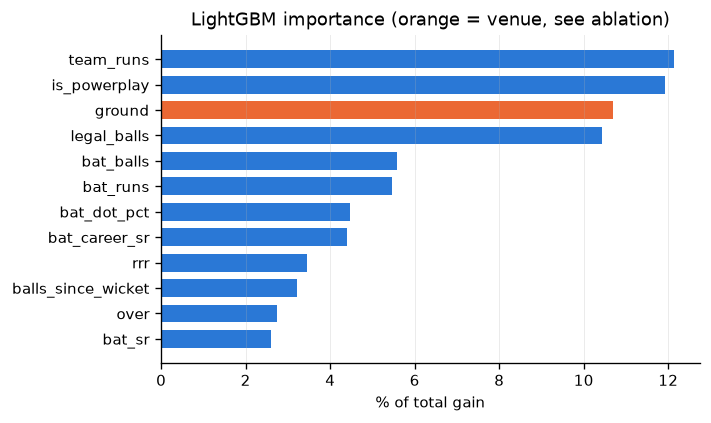

In [11]:
gains = sorted(zip(FEATS, lgbm.booster_.feature_importance("gain")), key=lambda t: -t[1])
total = sum(v for _, v in gains)
top = [(k, 100 * v / total) for k, v in gains[:12]][::-1]

fig, ax = plt.subplots(figsize=(6, 3.6))
colours = [ORANGE if k in ("ground", "venue_runs_per_ball", "venue_wicket_rate") else BLUE
           for k, _ in top]
ax.barh([k for k, _ in top], [v for _, v in top], color=colours, height=0.7)
ax.set(xlabel="% of total gain", title="LightGBM importance (orange = venue, see ablation)")
ax.grid(axis="y", visible=False)
plt.tight_layout()


In [12]:
def ablate(drop):
    feats = [f for f in FEATS if f not in drop]
    m = lgb.LGBMClassifier(**PARAMS, random_state=0)
    m.fit(frame(train, feats), ytr, eval_X=frame(val, feats), eval_y=yva,
          eval_metric="multi_logloss", callbacks=[lgb.early_stopping(100, verbose=False)])
    p = norm(m.predict_proba(frame(test, feats)))
    ll = log_loss(yte, p, labels=LABELS)
    return {"dropped": ", ".join(drop) if drop else "(nothing)",
            "logloss": round(ll, 5),
            "gain_%": round(100 * (NULL_LL - ll) / NULL_LL, 2),
            "boundary_AUC": round(roc_auc_score((yte >= 4).astype(int), p[:, 4] + p[:, 5]), 4)}


display(pl.DataFrame([
    ablate([]),
    ablate(["ground"]),
    ablate(["ground", "venue_runs_per_ball", "venue_wicket_rate"]),
    ablate(["h2h_dismissals", "h2h_balls"]),
    ablate(["bat_career_sr", "bat_career_dismissal_rate", "bat_career_balls"]),
]))


dropped,logloss,gain_%,boundary_AUC
str,f64,f64,f64
"""(nothing)""",1.35142,3.5,0.6158
"""ground""",1.34882,3.69,0.6171
"""ground, venue_runs_per_ball, v…",1.34985,3.62,0.6169
"""h2h_dismissals, h2h_balls""",1.35155,3.5,0.6154
"""bat_career_sr, bat_career_dism…",1.35611,3.17,0.6127


## Permutation importance, and the collinearity trap

Gain importance is measured while the trees are *built*. Permutation importance is measured on a
finished model: shuffle one column of the final-period data (an exploratory diagnostic, not a locked test) so it keeps its distribution but no longer
lines up with its rows, re-score, and charge the feature whatever that cost, expressed as a
share of the model's skill (the log-loss ground it gains over predicting the prior).

The catch is that a shuffled feature can be covered for by a surviving duplicate. Four columns
here encode the clock (`over`, `legal_balls`, `is_powerplay`, `phase`), so breaking any one
leaves the model three others. Shuffling them as a block is the honest measurement.


In [13]:
rng = np.random.default_rng(0)
ll_base = log_loss(yte, p_lgb, labels=LABELS)
skill = NULL_LL - ll_base


def perm_pct(cols, repeats=3):
    """% of skill lost when `cols` are shuffled together. Returns (mean, sd) over repeats."""
    Xp, losses = Xte.copy(), []
    for _ in range(repeats):
        idx = rng.permutation(len(Xp))      # one index for the whole group, so a collinear set
        for c in cols:                      # stays internally consistent (legal_balls is still
            Xp[c] = Xte[c].values[idx]      # 6 x over) and only its link to the outcome breaks
        losses.append(log_loss(yte, norm(lgbm.predict_proba(Xp)), labels=LABELS))
    for c in cols:
        Xp[c] = Xte[c]
    return 100 * (np.mean(losses) - ll_base) / skill, 100 * np.std(losses) / skill


groups = {f: [f] for f in FEATS}
groups["clock (over+legal_balls+is_powerplay+phase)"] = ["over", "legal_balls", "is_powerplay", "phase"]

rows = []
for name, cols in groups.items():
    pct, sd = perm_pct(cols)
    rows.append({"feature": name, "pct_of_skill": round(pct, 1), "sd": round(sd, 1)})

perm = pl.DataFrame(rows).sort("pct_of_skill", descending=True)
display(perm.head(18))


feature,pct_of_skill,sd
str,f64,f64
"""clock (over+legal_balls+is_pow…",54.2,1.6
"""is_powerplay""",12.4,0.2
"""team_runs""",10.6,0.7
"""team_wickets""",8.5,0.3
"""legal_balls""",7.9,0.5
…,…,…
"""rrr""",2.4,0.2
"""phase""",2.1,0.2
"""wickets_in_hand""",1.9,0.1


### Reading it

The clock block is 53% of skill. Individually `is_powerplay` is 11.9%, `legal_balls` 7.7%,
`phase` 2.0% and `over` 0.6%. They sum to 22%, less than half the joint figure, because each was
measured while the other three were still standing. When the model is told how late it is, it
is telling you most of what it knows.

Note also which of the four survives being measured alone: `is_powerplay`, a single bit, beats
the over number by 20×. The field restriction is the thing; the over is mostly a proxy for it.

The next tier is genuinely different information rather than another view of the clock:
`team_runs` (11%), `team_wickets` (8%), `bat_career_sr` (6%). That third one is the interesting
entry and it has no counterpart in the wicket model: who is on strike matters for scoring in a
way it barely does for dismissals. Dropping the three batter-career columns in the ablation
above costs more than dropping anything else.

At the bottom, the same negatives as the wicket notebook: `venue_runs_per_ball`, `bat_is_new`,
`bowl_runs` and `balls_left` all score at or below zero. Permuting them helps slightly, the
signature of a column the model has no use for.


---

# A second model, cut to what survived

Two findings feed into this:

1. Most features do nothing. Two thirds of the table scores inside the shuffle noise, and every
   one of them still costs the model capacity.
2. `ground` is the third-largest feature by gain and the ablation says dropping it *improves*
   the test loss. Venue does not earn its place here either.

So: keep the 15 that carry weight, and regularise harder now that there is less to overfit to
(`reg_lambda` 10 → 30, `min_child_samples` 400 → 1000, learning rate 0.03 → 0.02). Averaging
5 seeds removes the run-to-run wobble.


In [14]:
KEEP = ["is_powerplay", "team_runs", "team_wickets", "legal_balls", "bat_career_sr",
        "balls_since_wicket", "bat_runs", "bat_dot_pct", "bat_balls",
        "bat_career_dismissal_rate", "bowl_career_runs_per_ball", "rrr", "phase",
        "bat_sr", "bat_career_balls"]
print(f"{len(FEATS)} features -> {len(KEEP)}:  {', '.join(KEEP)}\n")

NEW = dict(PARAMS, n_estimators=4000, learning_rate=0.02, min_child_samples=1000,
           reg_lambda=30.0)


def ensemble(feats, params, n_seeds=5):
    """Fit n_seeds models and average their predicted distributions.

    Returns predictions on val as well as test: the calibration step below needs
    a set of predictions the model was not fitted on and that is not the test set.
    """
    a, b, c = (frame(d, feats) for d in (train, val, test))
    pv, pt = [], []
    for s in range(n_seeds):
        m = lgb.LGBMClassifier(**{**params, "random_state": s})
        m.fit(a, ytr, eval_X=b, eval_y=yva, eval_metric="multi_logloss",
              callbacks=[lgb.early_stopping(150, verbose=False)])
        pv.append(norm(m.predict_proba(b)))
        pt.append(norm(m.predict_proba(c)))
    return np.mean(pv, axis=0), np.mean(pt, axis=0)


p_new_va, p_new = ensemble(KEEP, NEW)

rows = []
for name, p in [("null (train prior)", NULL),
                ("multinomial + splines", p_lr),
                ("old: 37 features", p_lgb),
                ("new: 15 features, 5 seeds", p_new)]:
    p = norm(p)
    ll = log_loss(yte, p, labels=LABELS)
    null_row = name.startswith("null")
    rows.append({"model": name, "logloss": round(ll, 5),
                 "gain_%": round(100 * (NULL_LL - ll) / NULL_LL, 2),
                 "E_runs_RMSE": round(float(np.sqrt(np.mean((expected_runs(p) - runs_te) ** 2))), 4),
                 "boundary_AUC": None if null_row else round(roc_auc_score((yte >= 4).astype(int), p[:, 4] + p[:, 5]), 4)})
display(pl.DataFrame(rows))


37 features -> 15:  is_powerplay, team_runs, team_wickets, legal_balls, bat_career_sr, balls_since_wicket, bat_runs, bat_dot_pct, bat_balls, bat_career_dismissal_rate, bowl_career_runs_per_ball, rrr, phase, bat_sr, bat_career_balls



model,logloss,gain_%,E_runs_RMSE,boundary_AUC
str,f64,f64,f64,f64
"""null (train prior)""",1.4005,0.0,1.8607,null
"""multinomial + splines""",1.3526,3.42,1.8236,0.6154
"""old: 37 features""",1.35142,3.5,1.8205,0.6158
"""new: 15 features, 5 seeds""",1.34966,3.63,1.8176,0.6164


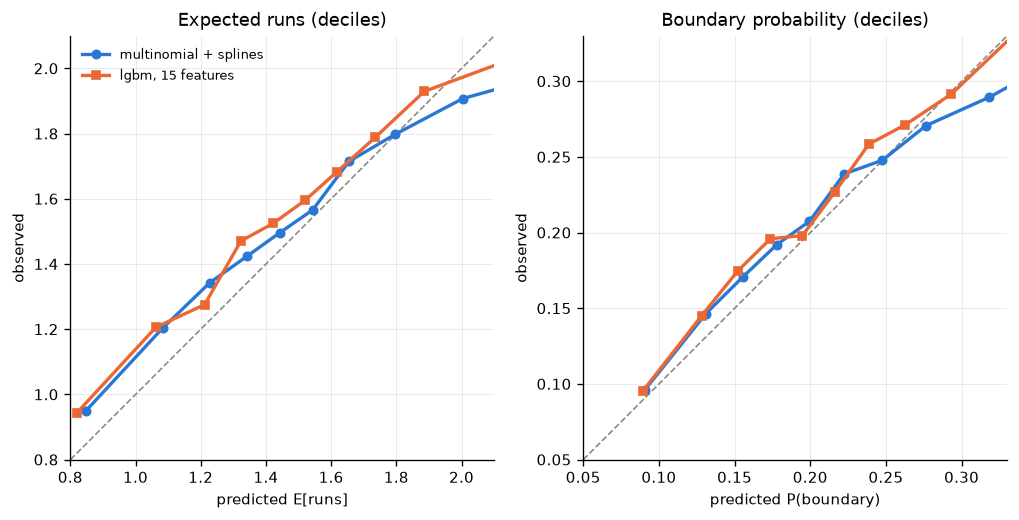

In [15]:
# Calibration of the final model, both views, against the baseline.
fig, axes = plt.subplots(1, 2, figsize=(8.6, 4.2))
for ax, score, actual, lo, hi, xl, t in [
        (axes[0], lambda p: expected_runs(p), runs_te, 0.8, 2.1,
         "predicted E[runs]", "Expected runs (deciles)"),
        (axes[1], lambda p: p[:, 4] + p[:, 5], (yte >= 4).astype(int), 0.05, 0.33,
         "predicted P(boundary)", "Boundary probability (deciles)")]:
    ax.plot([lo, hi], [lo, hi], color=GREY, lw=1, ls="--")
    for nm, p, colour, mk in [("multinomial + splines", p_lr, BLUE, "o"),
                              ("lgbm, 15 features", p_new, ORANGE, "s")]:
        c = cal_curve(score(p), actual)
        ax.plot(c["predicted"], c["actual"], marker=mk, ls="-", color=colour, lw=2, ms=5, label=nm)
    ax.set(xlabel=xl, ylabel="observed", title=t, xlim=(lo, hi), ylim=(lo, hi))
    ax.set_aspect("equal")
axes[0].legend(frameon=False, fontsize=8, loc="upper left")
plt.tight_layout()


### The era problem

Both calibration curves sit above the diagonal almost everywhere, and the shape plots show the
same thing: the model has the *shape* right and the *level* too low. This is not a modelling
error, it is drift. The training seasons averaged 1.29 runs per ball and the test seasons average
1.54. T20 scoring rose about 20% over the window, and a model fitted mostly on 2008–2019 cricket
carries the old level with it.


train mean 1.2923  ->  test mean 1.5448  (+19.5%)
model mean prediction on test: 1.4755  (-0.0693 per ball)


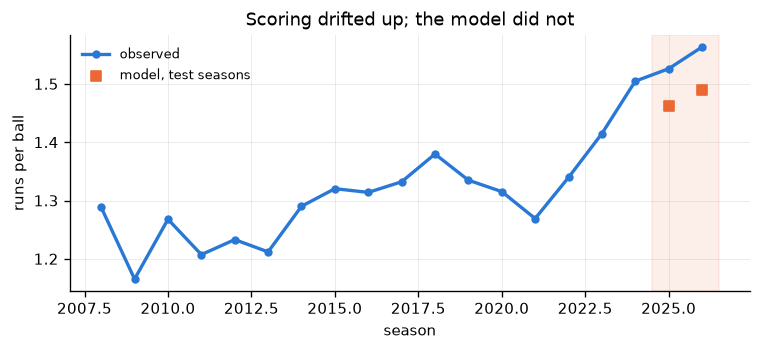

In [16]:
by_year = (pl.concat([train, val, test]).group_by("year")
             .agg(pl.col("_runs").mean().alias("actual")).sort("year"))
e_new = expected_runs(p_new)
print(f"train mean {np.array(OUTCOMES, float)[ytr].mean():.4f}  ->  "
      f"test mean {runs_te.mean():.4f}  (+{100 * (runs_te.mean() / np.array(OUTCOMES, float)[ytr].mean() - 1):.1f}%)")
print(f"model mean prediction on test: {e_new.mean():.4f}  "
      f"({e_new.mean() - runs_te.mean():+.4f} per ball)")

fig, ax = plt.subplots(figsize=(6.5, 3))
ax.plot(by_year["year"], by_year["actual"], "o-", color=BLUE, lw=2, ms=4, label="observed")
ax.axvspan(2024.5, 2026.5, color=ORANGE, alpha=0.10)
ax.scatter(test.select(pl.col("year")).to_series().unique().sort(),
           [pl.DataFrame({"y": test["year"], "e": e_new}).filter(pl.col("y") == yr)["e"].mean()
            for yr in sorted(test["year"].unique().to_list())],
           color=ORANGE, marker="s", zorder=3, label="model, test seasons")
ax.set(xlabel="season", ylabel="runs per ball", title="Scoring drifted up; the model did not")
ax.legend(frameon=False, fontsize=8)
plt.tight_layout()


The obvious fix, training only on recent seasons, does not work. Refitting the 15-feature model on
2018–2023 scores 3.53% and on 2021–2023 scores 3.49%, both worse than the 3.64% from all seasons,
and neither closes the level gap (mean prediction 1.462 and 1.456 against the full model's 1.473).
Throwing away 60–80% of the rows costs more in variance than the stale level costs in bias, and
the level is not really what the trees learned from the old seasons anyway: the *shape* transfers
fine, which is why log loss holds up.

The fix is a recalibration step rather than a data change: learn the correction on the validation
season and apply it to the test predictions, leaving the model alone. That is the next section.


## Recalibrating on the most recent season

The model has the ranking right and the level wrong, so the correction should move the level
without touching the ranking. Two candidates, both fitted on 2024 and applied unchanged to
2025–26. 2024 is also the validation season used for early stopping. It is separate from 2025–26, but it
is not a fully independent calibration set; the apparent benefit is therefore exploratory. In a
production pipeline, use a separate calibration window or out-of-fold predictions:

- **Prior shift.** For each outcome, compare how often the model said it would happen on the
  validation season against how often it did, and scale that class by the ratio. Six numbers.
- **Temperature.** Divide the logits by a scalar fitted to minimise validation log loss. The
  standard fix for over- or under-confidence.

They address different failures, and only one of them is the failure we have.


per-class weights fitted on 2024:
  0: 0.939
  1: 1.027
  2: 1.013
  3: 0.688
  4: 1.029
  6: 1.133

fitted temperature: 1.04


model,logloss,gain_%,mean_E_runs,E_runs_RMSE,boundary_AUC
str,f64,f64,f64,f64,f64
"""null (train prior)""",1.4005,0.0,1.2923,1.8607,null
"""15 features, uncalibrated""",1.34966,3.63,1.4755,1.8176,0.6164
"""+ temperature (T=1.04)""",1.34942,3.65,1.5085,1.8164,0.6163
"""+ prior shift""",1.34757,3.78,1.5531,1.8171,0.6163


actual mean runs per ball on test: 1.5448


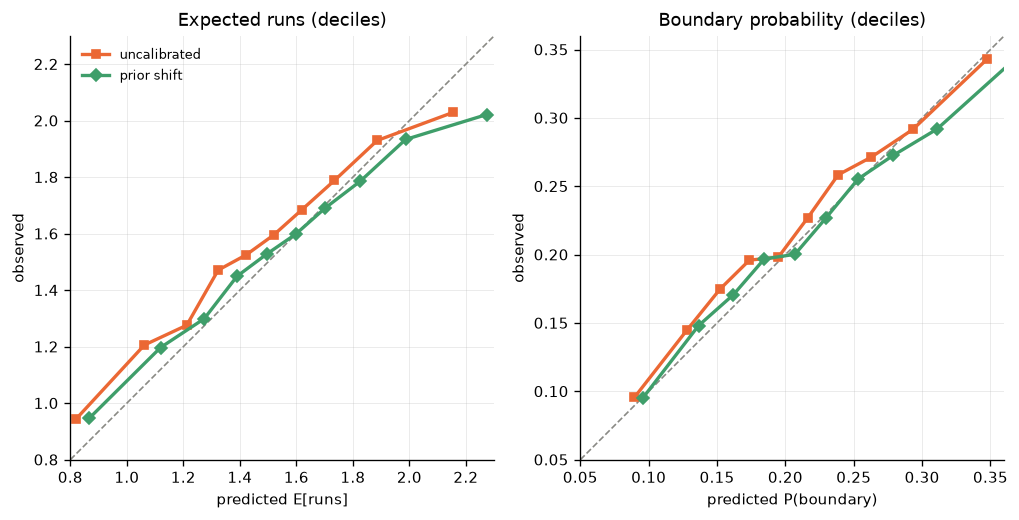

In [17]:
def prior_shift(p_fit, y_fit):
    """Per-class multiplicative correction: observed frequency / mean predicted probability."""
    obs = np.bincount(y_fit, minlength=len(OUTCOMES)) / len(y_fit)
    return obs / p_fit.mean(axis=0)


def temper(p, T):
    z = np.log(np.clip(p, 1e-12, None)) / T
    z -= z.max(axis=1, keepdims=True)
    return norm(np.exp(z))


W = prior_shift(p_new_va, yva)
grid = np.linspace(0.6, 1.6, 101)
T = float(grid[int(np.argmin([log_loss(yva, temper(p_new_va, t), labels=LABELS) for t in grid]))])

print("per-class weights fitted on 2024:")
for v, w in zip(OUTCOMES, W):
    print(f"  {v}: {w:.3f}")
print(f"\nfitted temperature: {T:.2f}")

p_cal = norm(p_new * W)

rows = []
for name, p in [("null (train prior)", NULL),
                ("15 features, uncalibrated", p_new),
                (f"+ temperature (T={T:.2f})", temper(p_new, T)),
                ("+ prior shift", p_cal)]:
    p = norm(p)
    ll = log_loss(yte, p, labels=LABELS)
    null_row = name.startswith("null")
    rows.append({"model": name, "logloss": round(ll, 5),
                 "gain_%": round(100 * (NULL_LL - ll) / NULL_LL, 2),
                 "mean_E_runs": round(float(expected_runs(p).mean()), 4),
                 "E_runs_RMSE": round(float(np.sqrt(np.mean((expected_runs(p) - runs_te) ** 2))), 4),
                 "boundary_AUC": None if null_row else round(roc_auc_score((yte >= 4).astype(int), p[:, 4] + p[:, 5]), 4)})
display(pl.DataFrame(rows))
print(f"actual mean runs per ball on test: {runs_te.mean():.4f}")

fig, axes = plt.subplots(1, 2, figsize=(8.6, 4.2))
for ax, score, actual, lo, hi, xl, t in [
        (axes[0], lambda p: expected_runs(p), runs_te, 0.8, 2.3,
         "predicted E[runs]", "Expected runs (deciles)"),
        (axes[1], lambda p: p[:, 4] + p[:, 5], (yte >= 4).astype(int), 0.05, 0.36,
         "predicted P(boundary)", "Boundary probability (deciles)")]:
    ax.plot([lo, hi], [lo, hi], color=GREY, lw=1, ls="--")
    for nm, p, colour, mk in [("uncalibrated", p_new, ORANGE, "s"),
                              ("prior shift", p_cal, GREEN, "D")]:
        cc = cal_curve(score(p), actual)
        ax.plot(cc["predicted"], cc["actual"], marker=mk, ls="-", color=colour, lw=2, ms=5, label=nm)
    ax.set(xlabel=xl, ylabel="observed", title=t, xlim=(lo, hi), ylim=(lo, hi))
    ax.set_aspect("equal")
axes[0].legend(frameon=False, fontsize=8, loc="upper left")
plt.tight_layout()


Prior shift appears to address the level error here; temperature does not. Six numbers fitted on one season take the
model from 3.63% to 3.78% over the prior, and the mean prediction from 1.476 to 1.553 against an
actual 1.545: the level error goes from 0.071 runs per ball to 0.008. Boundary AUC is unchanged
at 0.616, which is the point: the ranking was never the problem and the correction did not
disturb it.

Temperature buys 0.01% and should be read as a null result. T comes out at 1.04, a slight
*flattening*, and the mean prediction it produces (1.507) drifts up only as a side effect of
pushing mass toward the rare high-scoring classes. It is fixing confidence, and the model was not
overconfident, it was aimed at the wrong era.

Look at the weights themselves, because they are the era effect in six numbers: sixes ×1.14,
fours ×1.03, dots ×0.94. The change in T20 batting between the training seasons and now is
almost entirely six-hitting, which is what anyone watching would have told you, and the fitted correction reflects that same era shift. (The 3s weight of 0.69 is noise: that
class is 0.3% of balls.)

Two caveats, both visible in the plot. The correction is a single global adjustment, so it lands
the average and slightly over-corrects the top decile: the highest-scoring situations now predict
2.27 expected runs against an observed 2.03, where before they were roughly right. Trading a
small error everywhere for a larger one in the tail is the right trade for log loss, but if the
death overs are what you care about, fit the shift on those balls only.

And 2024 itself averaged 1.505 runs per ball against the test seasons' 1.545, so the correction is
fitted on an era already slightly behind the one it is applied to. It still overshoots the mean
rather than undershooting it, because the multiplicative form amplifies the tail classes. In
production this should be refitted every season.


### An innings, ball by ball

What the model is actually for. Expected runs and boundary probability tracked through a single
chase, with the delivered runs underneath.


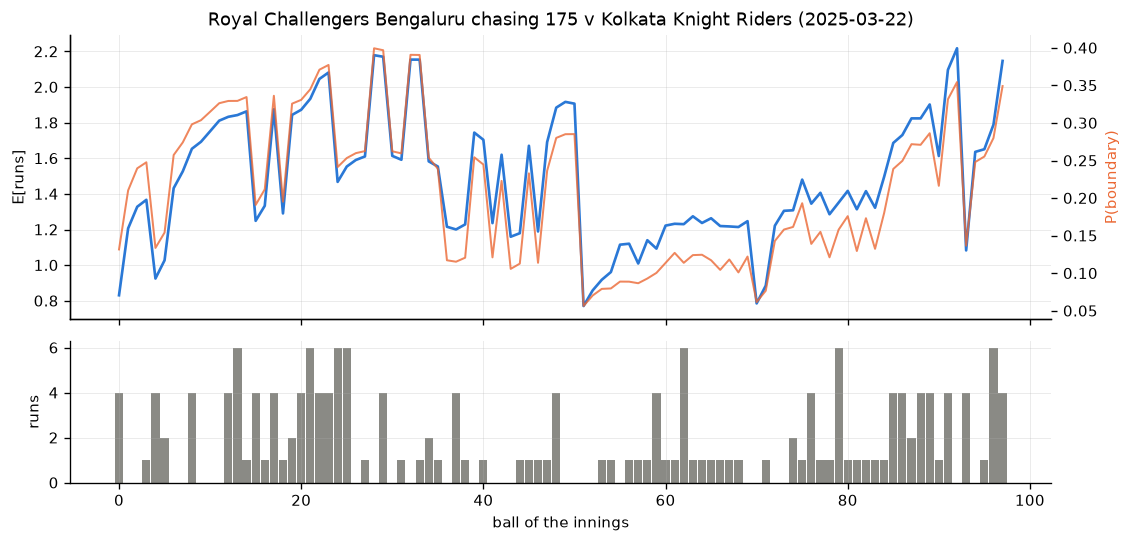

In [18]:
mid = test.filter(pl.col("innings") == 2)["match_id"][0]
inn = (test.with_columns(pl.Series("e_runs", expected_runs(p_cal)),
                         pl.Series("p_bnd", p_cal[:, 4] + p_cal[:, 5]))
           .filter((pl.col("match_id") == mid) & (pl.col("innings") == 2))
           .with_row_index("ball"))

fig, axes = plt.subplots(2, 1, figsize=(9.5, 4.6), sharex=True,
                         gridspec_kw={"height_ratios": [2, 1]})
axes[0].plot(inn["ball"], inn["e_runs"], color=BLUE, lw=1.6, label="E[runs]")
ax2 = axes[0].twinx()
ax2.plot(inn["ball"], inn["p_bnd"], color=ORANGE, lw=1.2, alpha=0.8, label="P(boundary)")
ax2.set_ylabel("P(boundary)", color=ORANGE)
ax2.grid(False)
axes[0].set(ylabel="E[runs]", title=f"{inn['batting_team'][0]} chasing "
            f"{inn['target_runs'][0]} v {inn['bowling_team'][0]} ({inn['date'][0]})")
axes[1].bar(inn["ball"], inn["_runs"], color=GREY, width=0.9)
axes[1].set(xlabel="ball of the innings", ylabel="runs", yticks=[0, 2, 4, 6])
plt.tight_layout()


---

# Bowler type: the feature that was not in the data

The next-steps list above called bowler type the largest missing signal, on the grounds that the
powerplay/middle-overs shape is substantially a pace-versus-spin split the model has to infer from
the over number. Cricsheet does not record it, so it had to be fetched.

`fetch_bowler_style.py` builds `player_style.csv` from three sources chained together: Cricsheet's
own register maps every player to a Cricinfo ID, Wikidata maps that ID to an en.wikipedia article,
and the article's infobox carries `bowling` and `batting` fields in prose that normalises cleanly.
Cricinfo itself is blocked to scripted requests, so its ID is used only as a join key. Wikidata's
own `bowling style` property (P2545) exists and is unusable - 43 of our 577 bowlers, and a value
distribution that is visibly bot-damaged. 25 uncapped players with no article were filled in by
hand; see `docs/BOWLER_STYLE_TODO.md`. Coverage is 577/577 bowlers, every delivery.

None of it is derived from the ball data, so there is nothing to leak: a bowler's action and a
batter's stance are fixed properties of the player, known before the season starts.

Four columns come out of it, and the last two are the interesting ones:

| column | |
|---|---|
| `bowler_type` | pace / spin |
| `bat_hand` | the striker's stance, for 99.7% of balls faced |
| `same_handed` | right-arm to a right-hander, left to a left |
| `turn_into_batter` | which way a spinner's ball moves relative to the bat |

`turn_into_batter` is the real cricket variable. Finger spin turns into a batter of the same
handedness as the bowling arm - an off-break into a right-hander, orthodox into a left-hander -
and wrist spin turns into the opposite one. It is null for pace, where turn is not the variable.


bowler_type,balls,runs_per_ball,boundary_rate,dot_rate,wicket_rate
str,u32,f64,f64,f64,f64
"""pace""",182116,1.3711,0.1942,0.3891,0.0541
"""spin""",102349,1.2679,0.1431,0.3462,0.0461


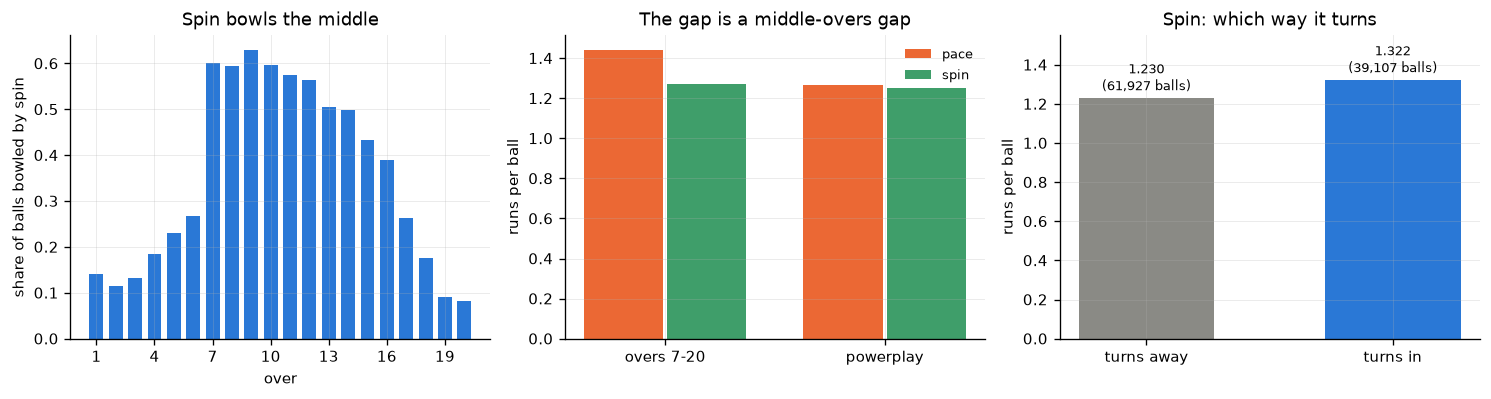

In [19]:
style = df                      # already legal-only, with _runs, from the first cell

fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.4))

# --- when each type bowls, which is what the model has been inferring ---
mix = (style.filter(pl.col("over") < 20).group_by("over")
            .agg((pl.col("bowler_type") == "spin").mean().alias("spin")).sort("over"))
axes[0].bar(mix["over"] + 1, mix["spin"], color=BLUE, width=0.72)
axes[0].set(xlabel="over", ylabel="share of balls bowled by spin",
            title="Spin bowls the middle", xticks=range(1, 21, 3))

# --- runs by type and phase ---
g = (style.group_by(["bowler_type", "is_powerplay"])
          .agg(pl.col("_runs").mean().alias("rpb"),
               (pl.col("_runs") >= 4).mean().alias("bnd")).sort("bowler_type", "is_powerplay"))
x = np.arange(2)
for i, (t, colour) in enumerate([("pace", ORANGE), ("spin", GREEN)]):
    v = g.filter(pl.col("bowler_type") == t).sort("is_powerplay")
    axes[1].bar(x + (i - 0.5) * 0.38, v["rpb"], width=0.36, color=colour, label=t)
axes[1].set(xticks=x, ylabel="runs per ball", title="The gap is a middle-overs gap")
axes[1].set_xticklabels(["overs 7-20", "powerplay"])
axes[1].legend(frameon=False, fontsize=8)

# --- the matchup ---
m = (style.filter(pl.col("bowler_type") == "spin")
          .drop_nulls("turn_into_batter").group_by("turn_into_batter")
          .agg(pl.len().alias("n"), pl.col("_runs").mean().alias("rpb"),
               (pl.col("_runs") >= 4).mean().alias("bnd")).sort("turn_into_batter"))
axes[2].bar(["turns away", "turns in"], m["rpb"], color=[GREY, BLUE], width=0.55)
for i, (r, n) in enumerate(zip(m["rpb"], m["n"])):
    axes[2].annotate(f"{r:.3f}\n({n:,} balls)", (i, r), ha="center", va="bottom",
                     xytext=(0, 2), textcoords="offset points", fontsize=8)
axes[2].set(ylabel="runs per ball", title="Spin: which way it turns", ylim=(0, 1.55))
plt.tight_layout()

display(style.group_by("bowler_type").agg(
    pl.len().alias("balls"), pl.col("_runs").mean().round(4).alias("runs_per_ball"),
    (pl.col("_runs") >= 4).mean().round(4).alias("boundary_rate"),
    (pl.col("_runs") == 0).mean().round(4).alias("dot_rate"),
    pl.col("wicket").mean().round(4).alias("wicket_rate")).sort("bowler_type"))


The raw gaps are big. Pace concedes 1.442 runs per ball outside the powerplay against spin's
1.271, with boundary rates of 18.5% and 13.6%. Spin turning into the bat goes for 1.322 against
1.230 turning away - the ball that comes on with the turn is the one you can hit through the line.

The middle panel is the warning, though: inside the powerplay pace and spin are level (1.266 vs
1.253). The type gap is a *middle-overs* gap, and the model already knows what over it is.


In [20]:
STYLE = ["bowler_type"]
MATCHUP = ["bowler_type", "bowler_arm", "bat_hand", "same_handed", "turn_into_batter"]
CATS_X = CATS + ["bowler_type", "bowler_arm", "bat_hand"]
levels_x = {c: sorted(raw[c].unique().drop_nulls().to_list()) for c in CATS_X}


def frame_x(d, feats):
    Xd = d.select(feats).to_pandas()
    for c in CATS_X:
        if c in feats:
            Xd[c] = pd.Categorical(Xd[c], categories=levels_x[c])
    return Xd


def ensemble_x(feats, params=NEW, n_seeds=5):
    a, b, c = (frame_x(d, feats) for d in (train, val, test))
    ps = []
    for s in range(n_seeds):
        m = lgb.LGBMClassifier(**{**params, "random_state": s})
        m.fit(a, ytr, eval_X=b, eval_y=yva, eval_metric="multi_logloss",
              callbacks=[lgb.early_stopping(150, verbose=False)])
        ps.append(norm(m.predict_proba(c)))
    return np.mean(ps, axis=0)


rows = []
style_predictions = {}
for name, feats in [("15 features (baseline)", KEEP),
                    ("+ bowler_type", KEEP + STYLE),
                    ("+ bowler_type, bat_hand", KEEP + ["bowler_type", "bat_hand"]),
                    ("+ full matchup", KEEP + MATCHUP)]:
    p = norm(ensemble_x(feats))
    style_predictions[name] = p
    ll = log_loss(yte, p, labels=LABELS)
    rows.append({"model": name, "n_feats": len(feats), "logloss": round(ll, 5),
                 "gain_%": round(100 * (NULL_LL - ll) / NULL_LL, 2),
                 "boundary_AUC": round(roc_auc_score((yte >= 4).astype(int), p[:, 4] + p[:, 5]), 4)})
    if name == "+ full matchup":
        p_style = p
display(pl.DataFrame(rows))


model,n_feats,logloss,gain_%,boundary_AUC
str,i64,f64,f64,f64
"""15 features (baseline)""",15,1.34966,3.63,0.6164
"""+ bowler_type""",16,1.34835,3.72,0.6174
"""+ bowler_type, bat_hand""",17,1.34833,3.72,0.6174
"""+ full matchup""",20,1.34811,3.74,0.6168


In [21]:
# Paired uncertainty: resample matches, not individual balls.
comparisons = [
    ("pruned vs old 37-feature model", p_lgb, p_new),
    ("prior shift vs uncalibrated", p_new, p_cal),
    ("+ bowler type vs pruned", p_new, style_predictions["+ bowler_type"]),
    ("+ full matchup vs pruned", p_new, style_predictions["+ full matchup"]),
]
uncertainty = []
for name, reference, candidate in comparisons:
    ci = clustered_log_loss_gain(
        yte, reference, candidate, test["match_id"].to_numpy(), n_boot=5_000
    )
    uncertainty.append({
        "comparison": name,
        "gain_x1e4": round(10_000 * ci.estimate, 2),
        "95%_low_x1e4": round(10_000 * ci.low, 2),
        "95%_high_x1e4": round(10_000 * ci.high, 2),
    })
display(pl.DataFrame(uncertainty))

comparison,gain_x1e4,95%_low_x1e4,95%_high_x1e4
str,f64,f64,f64
"""pruned vs old 37-feature model""",17.59,1.76,33.03
"""prior shift vs uncalibrated""",20.85,14.83,26.98
"""+ bowler type vs pruned""",13.12,4.62,21.6
"""+ full matchup vs pruned""",15.54,7.6,23.48


Positive values favour the named candidate; the units are $10^{-4}$ log-loss points. A 95%
"
            "interval that crosses zero means the apparent ordering is not stable across matches. This is a
"
            "more demanding and useful check than comparing random seeds on the same fixed rows.

### What it was worth

Smaller than the raw gaps suggest, but stable across matches within this explored final period.

| model | log loss | gain over prior |
|---|---|---|
| 15 features (baseline) | 1.34966 | +3.63% |
| + `bowler_type` | 1.34835 | +3.72% |
| + `bowler_type`, `bat_hand` | 1.34833 | +3.72% |
| + full matchup | 1.34811 | +3.74% |

The match-clustered interval for bowler type versus the pruned model is wholly positive on
2025–26. That is better evidence than seed variation, although it is still exploratory because
this period was inspected while choosing features. A future-season or rolling-origin repeat is
needed for an unbiased confirmation.

The size of the effect is modest because the model already has correlated proxies:
`bowl_career_runs_per_ball` partly identifies bowler type, while `is_powerplay` and `phase`
identify when that type tends to bowl. The new information is the residual within-bowler and
within-phase matchup.

Adding batting hand to bowler type barely changes the point estimate. The full matchup improves
over the no-style baseline, but this comparison does not isolate whether its extra gain over
`bowler_type` alone is reliable. A direct paired interval between those two variants would be the
appropriate test before making that narrower claim.

Style still earns consideration because it is actionable: type and matchup are levers a captain
can change when choosing who bowls the next over. That interpretability matters even when the
aggregate log-loss increment is small.

---

## Combining matchup features with independent calibration

The earlier style model and calibrator both looked useful, but the calibrator shared 2024 with
early stopping. This version gives every period exactly one job:

| period | job |
|---|---|
| 2008–2022 | estimate model parameters while selecting tree count against 2023 |
| 2023 | early stopping only |
| 2008–2023 | refit the selected model at its fixed tree count |
| 2024 | fit six regularized class intercepts only |
| 2025–26 | evaluation only within this experiment |

The calibration layer adds one bias to each class log-probability and renormalizes. It cannot
change delivery rankings or relearn feature effects; it can only correct class prevalence drift.
The rare classes are weakly regularized.

In [22]:
from model_runs_calibrated import fit_independent_style_model

independent = fit_independent_style_model(df, n_seeds=5, calibration_l2=1.0)
assert np.array_equal(independent.y_test, yte)

print(f"tree counts selected on 2023: {list(independent.best_iterations)}")
print("class biases fitted on 2024: " + "  ".join(
    f"{runs}:{bias:+.3f}" for runs, bias in zip(OUTCOMES, independent.bias)))

rows = []
for name, p in [
        ("null (train prior)", NULL),
        ("previous best: pruned + prior shift", p_cal),
        ("full matchup, independent raw", independent.raw_test),
        ("full matchup + independent bias", independent.calibrated_test)]:
    ll = log_loss(yte, p, labels=LABELS)
    null_row = name.startswith("null")
    rows.append({
        "model": name,
        "logloss": round(ll, 6),
        "gain_%": round(100 * (NULL_LL - ll) / NULL_LL, 3),
        "mean_E_runs": round(float(expected_runs(p).mean()), 4),
        "E_runs_RMSE": round(float(np.sqrt(np.mean((expected_runs(p) - runs_te) ** 2))), 4),
        "boundary_AUC": None if null_row else round(
            roc_auc_score((yte >= 4).astype(int), p[:, 4:].sum(axis=1)), 4),
    })
display(pl.DataFrame(rows))

comparisons = [
    ("independent calibration vs its raw model",
     independent.raw_test, independent.calibrated_test),
    ("combined model vs previous calibrated best", p_cal, independent.calibrated_test),
    ("combined model vs original 37-feature model", p_lgb, independent.calibrated_test),
]
rows = []
for name, reference, candidate in comparisons:
    ci = clustered_log_loss_gain(
        yte, reference, candidate, independent.test_match_ids, n_boot=5_000
    )
    rows.append({
        "comparison": name,
        "gain_x1e4": round(10_000 * ci.estimate, 2),
        "95%_low_x1e4": round(10_000 * ci.low, 2),
        "95%_high_x1e4": round(10_000 * ci.high, 2),
    })
display(pl.DataFrame(rows))

tree counts selected on 2023: [346, 383, 386, 339, 308]
class biases fitted on 2024: 0:-0.188  1:-0.104  2:-0.116  3:-0.500  4:-0.072  6:+0.000


model,logloss,gain_%,mean_E_runs,E_runs_RMSE,boundary_AUC
str,f64,f64,f64,f64,f64
"""null (train prior)""",1.400497,0.0,1.2923,1.8607,null
"""previous best: pruned + prior …",1.347574,3.779,1.5531,1.8171,0.6163
"""full matchup, independent raw""",1.348403,3.72,1.4705,1.8183,0.6157
"""full matchup + independent bia…",1.346543,3.853,1.5572,1.8174,0.6158


comparison,gain_x1e4,95%_low_x1e4,95%_high_x1e4
str,f64,f64,f64
"""independent calibration vs its…",18.6,12.62,24.74
"""combined model vs previous cal…",10.31,2.97,17.65
"""combined model vs original 37-…",48.75,32.28,65.32


Positive interval bounds mean the combined model wins across match resamples, not merely
across random training seeds. The comparison with the previous best is the key row: it tests
whether style and independently fitted calibration compound rather than duplicate one another.

The historical caveat still applies. Previous notebook versions inspected 2025–26, so this is a
methodologically cleaner experiment but not a magically restored pristine holdout. A future IPL
season or rolling-origin rerun remains the honest confirmation.

---

## Reading the result

There is more signal in runs than in wickets. The independently calibrated full-matchup
ensemble is the current best; its exact loss, gain, and uncertainty are in the table above, and the boundary
AUC of 0.616 is the number to look at: given one ball that went to the fence and one that did
not, the model ranks them correctly 62% of the time knowing nothing about the delivery itself.
The logistic regression is not far behind at 3.42%, which suggests much of the structure here is
additive; the trees' edge is small and should be read with the clustered interval above.

The point estimate barely improves, and that is not a failure. Expected-runs RMSE goes from
1.861 (prior) to 1.818. A single ball is 0, 1 or 4 and no amount of context changes that;
the variance is in the outcome, not in the estimate. Anyone reporting run prediction as an RMSE
is reporting a number that cannot move. The distribution is the product: P(boundary) on this
ball, aggregated over an over or an innings, and its calibration should be checked explicitly rather than assumed.

Venue does not pay, even here. This was the ablation worth running: the wicket notebook found
`ground` worthless but flagged that grounds differ by 1.30 to 1.51 runs per ball, so scoring was
where it should have mattered. It does not. Dropping `ground` and both venue-rate columns makes
the model slightly *better*. The between-ground scoring spread is real in the raw data but it is
already implied by what the other features say about how the innings is going: teams and
conditions are not independent of the state they produce.

What does pay, and did not for wickets, is the batter. `bat_career_sr` is the top non-clock
feature after the two innings-state columns, and dropping the batter-career block costs more than
any other ablation. Strike rate is a stable player property in a way that dismissal rate is not.

The independently calibrated matchup model is the strongest run component. The wicket and run
models together are the useful object: one gives P(wicket) and the other the run
distribution on the same delivery, which are useful inputs to a win-probability or simulation layer. A valid simulator still needs
legality/extras and the joint dependence between runs and wickets; multiplying two independent
marginal models is not enough.

The level was stale even though the shape was not, and that was the cheapest fix in the
notebook. Scoring rose ~20% across the window, and the uncalibrated model predicted 1.476 runs
per ball against an actual 1.545. AUC is blind to that because ranking can remain unchanged; log loss is not, and the calibration
error is one reason it worsens, which is exactly why a calibration plot belongs
in every writeup of a model like this. Regularized class biases fitted on the independent 2024 calibration window improve the full
matchup model from 3.72% to 3.85% gain. The ranking barely changes; the win is calibration.

### Next steps, roughly in order of expected value

1. ~~**Bowler type (pace/spin)**~~ and ~~**handedness matchup**~~ - both done, see the section
   above. Together with independent calibration, they reach 3.85% gain. The style-only increment is
   modest; calibration contributes the larger final step. The raw effects are large and almost entirely confounded with the clock.
2. **Ordinal structure in the head.** The six classes are not exchangeable: a model that
   confuses 4 and 6 is doing better than one that confuses 0 and 6, and multiclass log loss does
   not know that. Worth trying a cumulative-link head, or scoring with a distance-weighted loss.
3. **Model legality and extras**, so the forecast is unconditional before the ball is bowled.
4. **Feed P(wicket) in as a feature**, or fit the seven-way joint outcome (six run values plus
   dismissal) directly. The two processes compete for the same ball.
